# Sticky Expectations and Consumption Dynamics: the figures

This notebook regenerates the four figures in the
[sticky expectations handout](../content/consumption/StickyExpectationsC.md).
<!-- Provenance: the originals were drawn by `Code/Mathematica/doAll.nb` in the handout's
source zip, https://www.econ2.jhu.edu/people/ccarroll/public/LectureNotes/Consumption/StickyExpectationsC.zip.
The computation here is the same, except that the consumption function comes from
HARK's perfect foresight consumer instead of being written down by hand. -->
The consumption function comes from HARK's perfect foresight consumer.

The experiment: an economy that has had no income shocks draws an aggregate
transitory shock $\Theta_{t}=2$ in period $t$ and none afterward. The first two
figures show consumption $C$ and bank balances $B$ when every consumer is
omniscient. The second two add the path for an economy in which only a proportion
$\Pi$ of consumers update their expectations each period.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
from HARK.ConsumptionSaving.ConsIndShockModel import PerfForesightConsumerType

## Parameters

<!-- These are the values in `doAll.nb`, where the updating probability $\Pi$ is called $\lambda$. -->
Permanent income is fixed at $P=1$ ($\Gamma=1$ and no permanent
shocks), so levels and ratios to permanent income coincide.

In [2]:
r = 0.05
R = 1 + r
Pi = 0.5

periods = ["t-2", "t-1", "t", "t+1", "t+2", "t+3", "t+4", "t+5", "t+6", "t+7"]
T = len(periods)
shock_at = periods.index("t")

TranShk = np.ones(T)
TranShk[shock_at] = 2.0

## The consumption function, from HARK

The handout's consumption rule,

$$c_{t} = \left(b_{t} + (\theta_{t}-1)p_{t} + h_{t}\right)(r/R), \qquad h_{t} = \frac{p_{t}}{1-\Gamma/R},$$

is the optimal rule of a perfect foresight consumer with $R\beta=1$ who expects no
further shocks. HARK's `PerfForesightConsumerType` solves that problem. Its
solution is a function of market resources normalized by permanent income,
$m = b + \theta$, and with $R\beta=1$ the result does not depend on the coefficient
of relative risk aversion.

In [3]:
agent = PerfForesightConsumerType(
    cycles=0,
    CRRA=2.0,
    Rfree=[R],
    DiscFac=1 / R,
    LivPrb=[1.0],
    PermGroFac=[1.0],
    BoroCnstArt=None,
)
agent.tolerance = 1e-12
agent.solve()
cFunc = agent.solution[0].cFunc

m_grid = np.linspace(-5.0, 5.0, 11)
h = 1 / (1 - 1 / R)
handout_rule = (m_grid - 1 + h) * r / R
assert np.allclose(cFunc(m_grid), handout_rule, atol=1e-9)
print(f"MPC = {agent.solution[0].MPCmin:.6f}   r/R = {r / R:.6f}")

MPC = 0.047619   r/R = 0.047619


## Aggregate dynamics

Every consumer experiences the same shocks, and the updaters in each period are a
random sample of the population. Their average market resources therefore equal the
aggregate $M_{t}$, and because the consumption function is linear, their average
consumption is $\mathrm{c}(M_{t})$. Everyone else repeats last period's consumption,
so

$$C_{t} = \Pi\, \mathrm{c}(M_{t}) + (1-\Pi)\, C_{t-1}.$$

With $\Pi=1$ this is the omniscient economy. <!-- This is the recursion `doAll.nb` iterates in `AddPeriod`. -->
The economy starts in the steady state $B=0$, $C=1$.

In [4]:
def simulate(TranShk, Pi, cFunc):
    """Return the paths of aggregate B and C when a proportion Pi updates each period."""
    B = np.zeros(len(TranShk))
    C = np.zeros(len(TranShk))
    A_prev, C_prev = 0.0, float(cFunc(1.0))
    for t, theta in enumerate(TranShk):
        B[t] = R * A_prev
        M = B[t] + theta
        C[t] = Pi * cFunc(M) + (1 - Pi) * C_prev
        A_prev, C_prev = M - C[t], C[t]
    return B, C


B_omni, C_omni = simulate(TranShk, 1.0, cFunc)
B_stick, C_stick = simulate(TranShk, Pi, cFunc)

print(f"{'':>5} {'C omniscient':>13} {'C sticky':>10} {'B omniscient':>13} {'B sticky':>10}")
for row in zip(periods, C_omni, C_stick, B_omni, B_stick):
    print(f"{row[0]:>5} {row[1]:13.5f} {row[2]:10.5f} {row[3]:13.5f} {row[4]:10.5f}")

       C omniscient   C sticky  B omniscient   B sticky
  t-2       1.00000    1.00000       0.00000    0.00000
  t-1       1.00000    1.00000       0.00000    0.00000
    t       1.04762    1.02381       0.00000    0.00000
  t+1       1.04762    1.03631       1.00000    1.02500
  t+2       1.04762    1.04287       1.00000    1.03812
  t+3       1.04762    1.04632       1.00000    1.04502
  t+4       1.04762    1.04813       1.00000    1.04863
  t+5       1.04762    1.04908       1.00000    1.05053
  t+6       1.04762    1.04957       1.00000    1.05153
  t+7       1.04762    1.04984       1.00000    1.05205


### Checks against the handout

Omniscient consumers spend the annuity value $r/R$ of the windfall immediately and
forever, and bank the rest, so $B$ rises by $1$ once and stays there. With sticky
expectations, consumption rises by $\Pi\,(r/R)$ on impact, and after that the
handout's result $\Delta C_{t+1} = (1-\Pi)R\,\Delta C_{t} + \xi_{t+1}$ holds with
$\xi=0$, because there are no further shocks.

In [5]:
assert np.allclose(C_omni[:shock_at], 1.0)
assert np.allclose(C_omni[shock_at:], 1 + r / R)
assert np.allclose(B_omni[shock_at + 1 :], 1.0)

dC = np.diff(C_stick)
assert np.isclose(dC[shock_at - 1], Pi * r / R)
assert np.allclose(dC[shock_at:], (1 - Pi) * R * dC[shock_at - 1 : -1])
print("Paths match the handout's analytical results.")

Paths match the handout's analytical results.


### A check by simulating individual consumers

<!-- The aggregate recursion depends on the handout's argument that updaters are
representative of the population. As a check, we simulate that population
directly: each of $N$ consumers updates with probability $\Pi$, using HARK's
consumption function on his own market resources, and otherwise keeps his
consumption unchanged. The population averages match the aggregate recursion up to
sampling error. -->

In [6]:
rng = np.random.default_rng(0)
N = 200_000
a = np.zeros(N)
c = np.full(N, float(cFunc(1.0)))
B_pop, C_pop = np.zeros(T), np.zeros(T)
for t, theta in enumerate(TranShk):
    b = R * a
    m = b + theta
    updates = rng.random(N) < Pi
    c = np.where(updates, cFunc(m), c)
    a = m - c
    B_pop[t], C_pop[t] = b.mean(), c.mean()

print(f"largest gap in C: {np.abs(C_pop - C_stick).max():.1e}")
print(f"largest gap in B: {np.abs(B_pop - B_stick).max():.1e}")
assert np.abs(C_pop - C_stick).max() < 1e-3
assert np.abs(B_pop - B_stick).max() < 1e-2

largest gap in C: 4.2e-05
largest gap in B: 1.7e-04


## Figures

<!-- The styling follows Mathematica's `ListPlot` defaults as used in `doAll.nb`:
axes without a frame, labelled at their ends; the time axis spans [0, 10.2];
omniscient consumption in Mathematica's default blue, omniscient balances in black,
and the sticky economy in red. -->
The figures are written to `figures/StickyExpectationsC/` beside this notebook,
under the file names the handout uses.

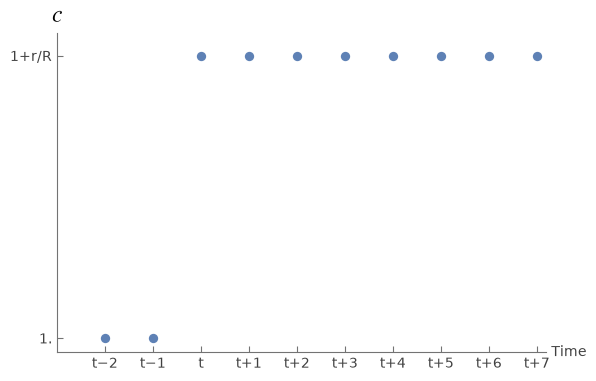

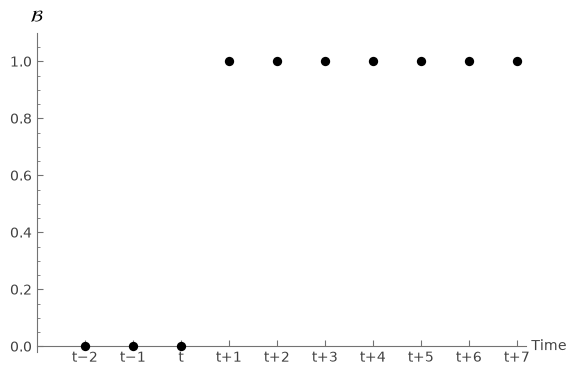

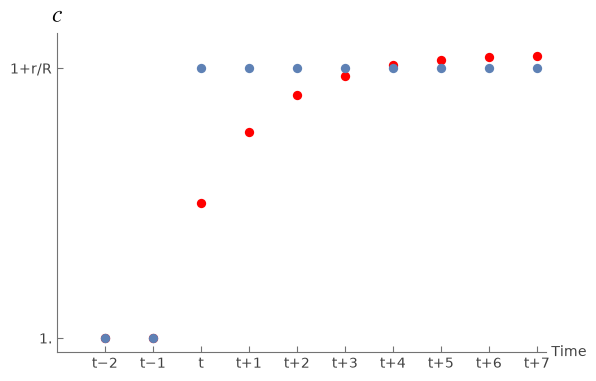

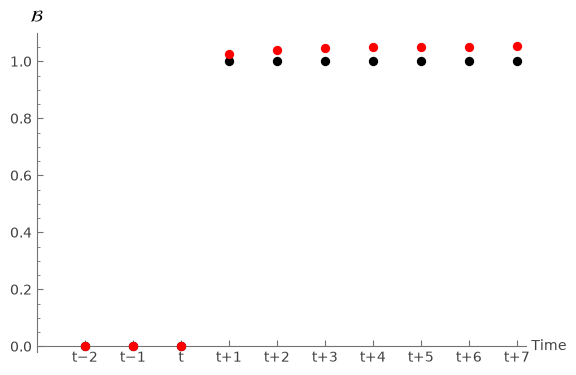

In [7]:
FIG_DIR = Path("figures") / "StickyExpectationsC"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Provenance: the axis range [0, 10.2], the figure size 6.12 x 3.8, and the
# default plot blue below match Mathematica's ListPlot defaults in
# Code/Mathematica/doAll.nb.
BLUE = (0.368417, 0.506779, 0.709798)
BLACK = (0.0, 0.0, 0.0)
RED = (1.0, 0.0, 0.0)
AXIS_GRAY = "0.45"
x = np.arange(1, T + 1)


def listplot(series, ylabel, yticks, ylim, x_axis_at, minor_yticks=None):
    """Draw point series (y, color), later ones on top."""
    fig, ax = plt.subplots(figsize=(6.12, 3.8))
    fig.subplots_adjust(left=0.1, right=0.9, top=0.92, bottom=0.08)
    for y, color in series:
        ax.scatter(x, y, s=45, color=color, linewidths=0, zorder=3, clip_on=False)

    ax.set_xlim(0, 10.2)
    ax.set_ylim(*ylim)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_position(("data", x_axis_at))
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS_GRAY)
        ax.spines[side].set_linewidth(0.8)

    ax.set_xticks(x, [p.replace("-", "\u2212") for p in periods])
    ax.set_yticks([v for v, _ in yticks], [s for _, s in yticks])
    if minor_yticks is not None:
        ax.set_yticks(minor_yticks, minor=True)
    ax.tick_params(which="both", direction="in", color=AXIS_GRAY, labelcolor="0.25", labelsize=10)
    ax.tick_params(which="major", length=4)
    ax.tick_params(which="minor", length=2)

    end_of_x_axis = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(1.01, x_axis_at, "Time", transform=end_of_x_axis, ha="left", va="center", color="0.25")
    ax.text(0.0, 1.02, ylabel, transform=ax.transAxes, ha="center", va="bottom", fontsize=12)
    return fig


def c_limits(*paths):
    lo = min(p.min() for p in paths)
    hi = max(p.max() for p in paths)
    span = hi - lo
    return lo - 0.05 * span, hi + 0.08 * span


C_TICKS = [(1.0, "1."), (1 + r / R, "1+r/R")]
B_TICKS = [(v, f"{v:.1f}") for v in np.arange(0.0, 1.01, 0.2)]
B_LIM = (-0.02, 1.1)
B_MINOR = np.arange(0.0, 1.1, 0.05)

figures = {
    "cPlot": listplot(
        [(C_omni, BLUE)],
        r"$\mathcal{C}$",
        C_TICKS,
        c_limits(C_omni),
        x_axis_at=c_limits(C_omni)[0],
    ),
    "bPlot": listplot(
        [(B_omni, BLACK)], r"$\mathcal{B}$", B_TICKS, B_LIM, x_axis_at=0.0, minor_yticks=B_MINOR
    ),
    "StickyExpectationsCc": listplot(
        [(C_stick, RED), (C_omni, BLUE)],
        r"$\mathcal{C}$",
        C_TICKS,
        c_limits(C_omni, C_stick),
        x_axis_at=c_limits(C_omni, C_stick)[0],
    ),
    "StickyExpectationsCb": listplot(
        [(B_omni, BLACK), (B_stick, RED)],
        r"$\mathcal{B}$",
        B_TICKS,
        B_LIM,
        x_axis_at=0.0,
        minor_yticks=B_MINOR,
    ),
}

for name, fig in figures.items():
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    fig.savefig(FIG_DIR / f"{name}.svg")
plt.show()

## Side by side with the figures in the handout

<!-- Side by side with the Mathematica originals.
The left column shows the figures the book currently uses, which are the files
`doAll.nb` exported. The right column shows the figures regenerated above. -->

The left column shows the figures the handout currently uses. The right column shows the figures regenerated above.

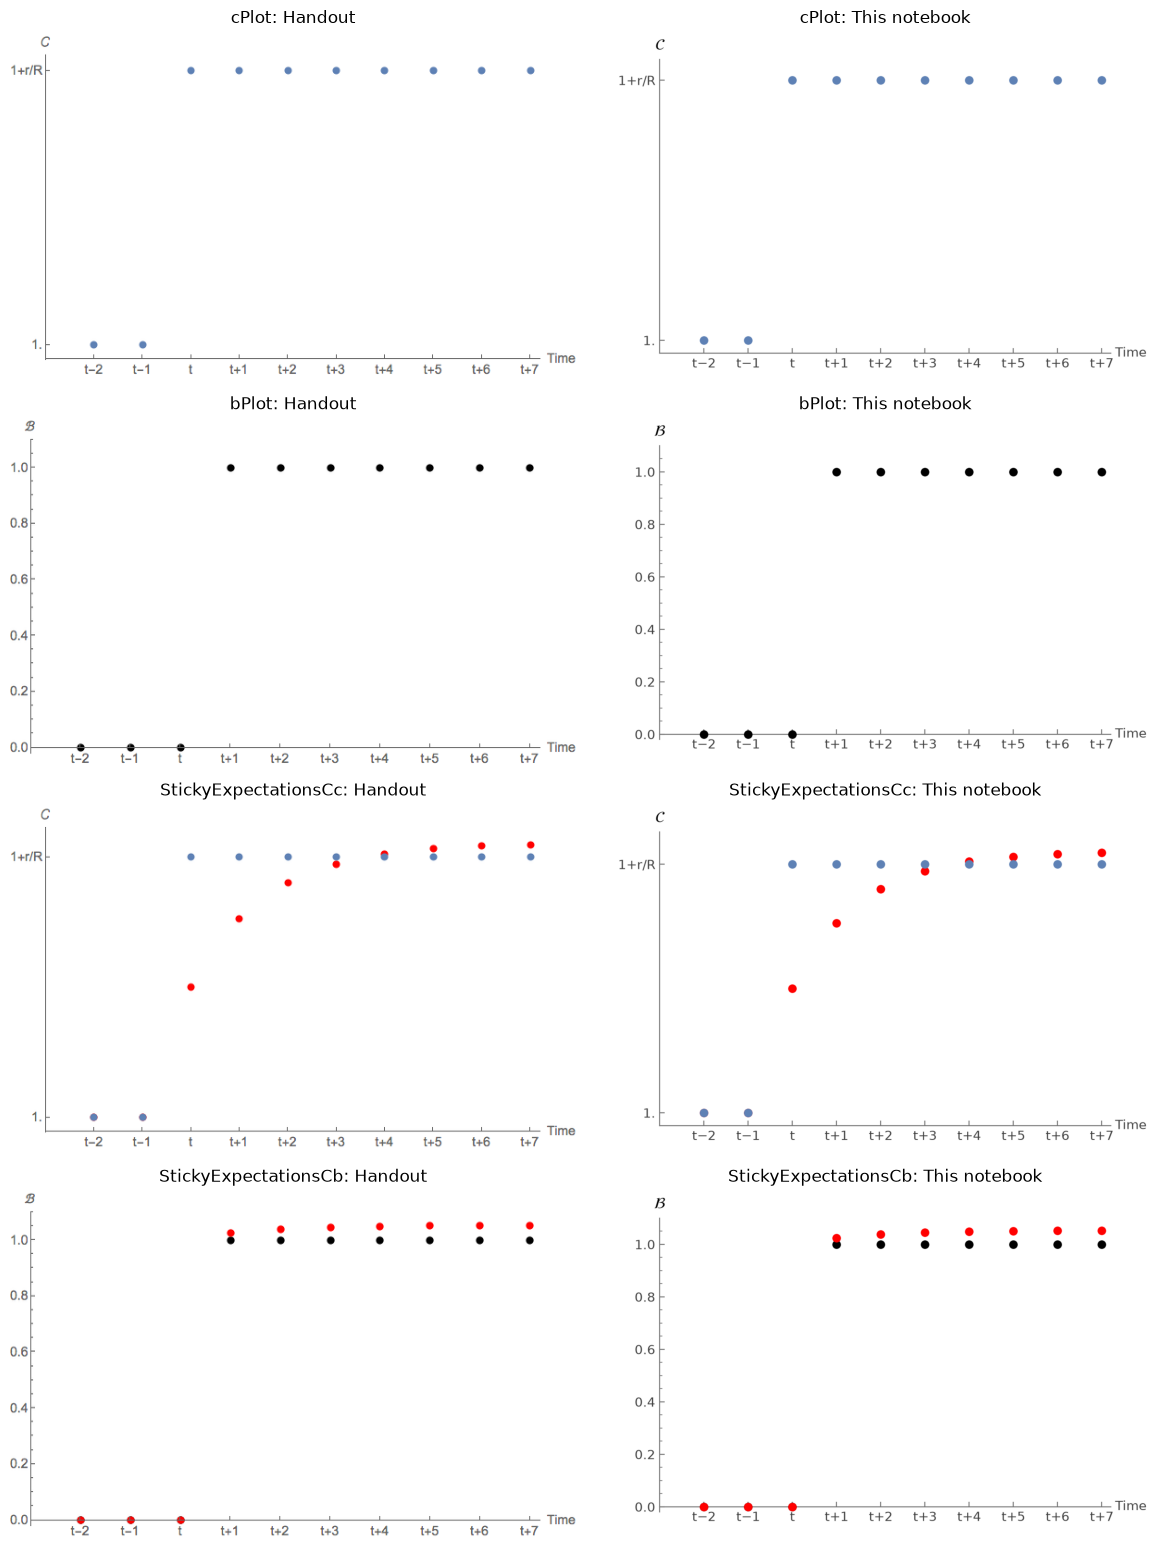

In [8]:
ORIGINALS = Path("..") / "content" / "figures" / "StickyExpectationsC"

fig, axes = plt.subplots(len(figures), 2, figsize=(12, 3.9 * len(figures)))
for row, name in zip(axes, figures):
    for ax, path, title in zip(
        row,
        (ORIGINALS / f"{name}.png", FIG_DIR / f"{name}.png"),
        # ("Mathematica", "This notebook"),
        ("Handout", "This notebook"),
    ):
        ax.imshow(plt.imread(path))
        ax.set_title(f"{name}: {title}")
        ax.axis("off")
fig.tight_layout()
plt.show()